In [1]:
import pandas as pd
import os
import json
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis, FeaturePredictiveEvaluator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import time

In [2]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [3]:
# Enable automatic reloading of modules before executing user code (useful during development)
%load_ext autoreload
%autoreload 2

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "country_panel_data")
RAW_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "raw_data")
PARQUET_PATH = os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars.parquet")
JSON_METADATA_PATH =os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars_metadata.json")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

In [5]:
# Load dataframe
df = pd.read_parquet(PARQUET_PATH)
df.head()

,iso_alpha_3,year,country_name,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,...,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
0,AFG,2002,Afghanistan,3.825701e+09,338.139974,926.507941,21378117.0,0.220,0.084,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AFG,2003,Afghanistan,4.520947e+09,346.071627,966.962032,22733049.0,0.227,0.086,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AFG,2004,Afghanistan,5.224897e+09,338.637274,971.633503,23560654.0,0.238,0.091,0.931,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AFG,2005,Afghanistan,6.203257e+09,363.640141,1076.087353,24404567.0,0.319,0.113,0.942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AFG,2006,Afghanistan,6.971758e+09,367.758312,1121.834471,25424094.0,0.373,0.199,0.955,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 71 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   iso_alpha_3                                2856 non-null   object 
 1   year                                       2856 non-null   int64  
 2   country_name                               2856 non-null   object 
 3   cap_gdp_current_usd                        2856 non-null   float64
 4   cap_gdp_per_capita_constant_2015           2856 non-null   float64
 5   cap_gdp_per_capita_ppp_current             2856 non-null   float64
 6   cap_population                             2856 non-null   float64
 7   cap_electoral_democracy_idx                2856 non-null   float64
 8   cap_liberal_democracy_idx                  2856 non-null   float64
 9   cap_corruption_idx                         2856 non-null   float64
 10  cap_rule_of_law_idx     

In [7]:
# Load metadata
with open(JSON_METADATA_PATH, "r") as file:
    df_metadata = json.load(file) 
df_metadata.keys()

dict_keys(['configuration', 'dimensions', 'zero_filled_variables'])

In [8]:
# Obtain emission fields
emission_fields = df_metadata["dimensions"]["EMISSIONS"]
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_mt',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [9]:
df[emission_fields]

,con_co2_incl_luc_mt,con_co2_intensity,con_co2_mt,con_co2_per_capita,con_edgar_ghg_mt,con_edgar_ghg_gg,con_ghg_per_capita,con_methane_mt,con_nitrous_oxide_mt,con_share_global_co2_pct,con_total_emissions,con_total_ghg_mt
0,6.391,169.01,1.341,0.063,17.044710,17044.710352,0.937,10.375,3.299,0.005,0.12,20.037
1,6.169,241.76,1.560,0.069,17.732318,17732.317739,0.914,10.687,3.434,0.006,0.22,20.769
2,3.636,227.85,1.237,0.053,17.789451,17789.451447,0.804,10.651,3.412,0.004,0.18,18.934
3,2.983,219.51,1.890,0.077,18.191324,18191.324358,0.787,10.901,3.561,0.006,0.18,19.199
4,3.244,255.56,2.159,0.085,18.461036,18461.036258,0.764,11.122,3.418,0.007,0.23,19.426
...,...,...,...,...,...,...,...,...,...,...,...,...
2851,10.131,395.55,11.209,0.746,31.273375,31273.374543,1.813,11.831,5.206,0.031,3.73,27.250
2852,16.597,429.25,10.267,0.672,30.207339,30207.339246,2.008,11.636,5.099,0.028,3.64,30.672
2853,7.897,371.09,8.491,0.547,28.341567,28341.566541,1.555,11.314,4.591,0.024,2.49,24.146
2854,12.444,269.55,10.223,0.647,29.525357,29525.356700,1.767,11.840,4.858,0.028,2.31,27.907


In [10]:
# define target variable
target_var = "con_edgar_ghg_mt"

## Data prep

### Filter data to avoid leakage

In [11]:
emission_fields.remove(target_var)
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [12]:
df_filtered = df.drop(columns=emission_fields + ["country_name"])
df_filtered.columns

Index(['iso_alpha_3', 'year', 'cap_gdp_current_usd',
       'cap_gdp_per_capita_constant_2015', 'cap_gdp_per_capita_ppp_current',
       'cap_population', 'cap_electoral_democracy_idx',
       'cap_liberal_democracy_idx', 'cap_corruption_idx',
       'cap_rule_of_law_idx', 'cap_accountability_idx',
       'cap_civil_liberties_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_political_stability',
       'cap_regulatory_quality', 'cap_rule_of_law', 'cap_voice_accountability',
       'con_agricultural_land_pct', 'con_bioenergy', 'con_coal', 'con_demand',
       'con_demand_per_capita', 'con_electricity_access_pct',
       'con_electricity_generation_twh', 'con_energy_per_capita_kwh',
       'con_forest_area_pct', 'con_fossil_share_elec_pct', 'con_gas',
       'con_gas_and_other_fossil', 'con_hydro',
       'con_hydro,_bioenergy_and_other_renewables', 'con_net_elec_imports_twh',
       'con_nuclear', 'con_other_fossil', 'con_population',
       'con_primary_energy_twh'

### Filter some redoundant variables

In [13]:
redoundant_fields = [
    "cap_gdp_per_capita_constant_2015",
    "cap_gdp_current_usd",
    "con_population",
    "cap_population",
    "cap_electoral_democracy_idx",
    "cap_accountability_idx",
    "con_electricity_generation_twh",
    "con_total_generation",
    "con_gas_and_other_fossil",
    "con_hydro,_bioenergy_and_other_renewables",
    "con_ndgain_readiness",
    "inc_n_policies_total",
    "inc_n_sectors_covered",
]

In [14]:
df_filtered = df_filtered.drop(columns=redoundant_fields)

### Add Policy Stringency Index data

In [15]:
#TODO
policy_index_df = pd.read_csv(os.path.join(RAW_DATA_DIR_PATH, "policy_index", "ClimatePolicyDatabase_v2025.csv"))
policy_index_df.head()

,policy_id,country_iso,country_update,policy_title,policy_name,jurisdiction,supranational_region,country,subnational_region,policy_city_or_local,...,end_date,high_impact,policy_objective,reference,last_update,impact_indicators.comments,impact_indicators.name,impact_indicators.value,impact_indicators.base_year,impact_indicators.target_year
0,211000001,ITA,Sporadic,"""All inclusive"" Feed-in Tariff for small renew...","""All inclusive"" Feed-in Tariff for small renew...",Country,NaN,Italy,NaN,NaN,...,NaN,Unknown,Mitigation,https://www.iea.org/policies/4673-feed-in-tari...,NaN,NaN,NaN,NaN,NaN,NaN
1,211000002,DEU,Annual,"""Energy of the Future"" monitoring process Germ...","""Energy of the Future"" monitoring process",Country,NaN,Germany,NaN,NaN,...,NaN,Unknown,Mitigation,https://www.bmwi.de/Redaktion/EN/Artikel/Energ...,NaN,NaN,NaN,NaN,NaN,NaN
2,211000003,DEU,Annual,"""Energy-efficient Systems in Trade and Industr...","""Energy-efficient Systems in Trade and Industr...",Country,NaN,Germany,NaN,NaN,...,2007.0,Unknown,Mitigation,http://www.stromeffizienz.de/,NaN,NaN,NaN,NaN,NaN,NaN
3,211000004,FRA,Sporadic,"""Investment for the Future"" Programme France (...","""Investment for the Future"" Programme",Country,NaN,France,NaN,NaN,...,NaN,Unknown,Mitigation,https://www.iea.org/policies/3115-investment-f...,NaN,NaN,NaN,NaN,NaN,NaN
4,211000005,KOR,Annual,"""Kids ISO 14000 Program"" for Energy Conservati...","""Kids ISO 14000 Program"" for Energy Conservati...",Country,NaN,Republic of Korea,NaN,NaN,...,NaN,Unknown,Mitigation,http://www.iso.org/iso/en/kidsiso14000/index.html,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
print("Number of rows: ", policy_index_df.shape[0])
print("="*50)
print("NaNs per column: ", policy_index_df.isna().sum())

Number of rows:  6727
NaNs per column:  policy_id                           0
country_iso                         0
country_update                      2
policy_title                        0
policy_name                         0
jurisdiction                        0
supranational_region             6727
country                             0
subnational_region               6571
policy_city_or_local             6683
policy_instrument                   1
sector                              0
policy_description               1771
policy_type                         9
stringency                       6621
policy_status                       0
decision_date                       8
start_date                       5367
end_date                         5046
high_impact                      1479
policy_objective                    0
reference                          43
last_update                      4696
impact_indicators.comments       6357
impact_indicators.name           6312
impact_ind

In [17]:
print("Policy status value counts: ", policy_index_df["policy_status"].value_counts())
print("="*50)
print("Decision years: ", policy_index_df["decision_date"].unique())
print("="*50)
print("Amount of unique countries: ", policy_index_df["country_iso"].nunique())

Policy status value counts:  policy_status
In force        4960
Ended           1147
Superseded       540
Planned           43
Unknown           19
Draft             13
Under review       5
Name: count, dtype: int64
Decision years:  [2008. 2011. 2004. 2014. 2005. 2020. 2015. 2000. 2006. 1999. 1995. 2001.
 2012. 2016. 2007. 1986. 2009. 2010. 2019. 2013. 2017. 2018. 1989. 2003.
 2002. 1994. 1998. 1992. 1966. 1968. 1981. 1988. 1965. 1954. 1993. 1996.
 1980. 1997. 1982. 1970. 1990. 2022. 1979. 1991. 1975. 1976. 1978. 1983.
 1985. 1956. 1964. 1984. 1974. 1977. 1987. 1971. 1927. 1944. 1941. 1958.
 2021. 2023.   nan 2024. 2025. 2026.]
Amount of unique countries:  198


In [18]:
# keep only the In force, Ended and Superseded policies
policy_index_df = policy_index_df[policy_index_df["policy_status"].isin(["In force", "Ended", "Superseded"])]
print("Policy status value counts after filtering: ", policy_index_df["policy_status"].value_counts())

Policy status value counts after filtering:  policy_status
In force      4960
Ended         1147
Superseded     540
Name: count, dtype: int64


In [19]:
# keep only the relevant columns
policy_index_df = policy_index_df[["country_iso", "decision_date", "policy_title"]]
# rename columns
policy_index_df = policy_index_df.rename(columns={"country_iso": "iso_alpha_3", "decision_date": "year"})
policy_index_df.head()

,iso_alpha_3,year,policy_title
0,ITA,2008.0,"""All inclusive"" Feed-in Tariff for small renew..."
1,DEU,2011.0,"""Energy of the Future"" monitoring process Germ..."
2,DEU,2004.0,"""Energy-efficient Systems in Trade and Industr..."
3,FRA,2014.0,"""Investment for the Future"" Programme France (..."
4,KOR,2005.0,"""Kids ISO 14000 Program"" for Energy Conservati..."


In [20]:
policy_index_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6647 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   iso_alpha_3   6647 non-null   object 
 1   year          6647 non-null   float64
 2   policy_title  6647 non-null   object 
dtypes: float64(1), object(2)
memory usage: 207.7+ KB


In [21]:
policy_index_df[policy_index_df["iso_alpha_3"] == "MEX"]

,iso_alpha_3,year,policy_title
73,MEX,2005.0,Accelerated Depreciation for Investments with ...
131,MEX,1992.0,Agrarian Law Mexico (1992)
389,MEX,2014.0,Carbon Tax Mexico (2014)
469,MEX,2012.0,Climate Change Fund Mexico (2012)
612,MEX,2006.0,Diesel Heavy Duty Vehicle Emissions Standards ...
...,...,...,...
6625,MEX,2025.0,Updated National Climate Change Strategy Visio...
6626,MEX,2019.0,Roadmap for Implementing the Kigali Amendment ...
6627,MEX,2025.0,National Environmental Restoration Program 202...
6628,MEX,2025.0,Plan Mexico Mexico (2025)


In [22]:
#TODO: Aggregate the df by counting the policies per country-year
policy_index_agg = policy_index_df.groupby(["iso_alpha_3", "year"]).size().reset_index(name="policy_count")
policy_index_agg.head()

,iso_alpha_3,year,policy_count
0,AFG,2014.0,1
1,AFG,2015.0,1
2,AGO,2008.0,2
3,AGO,2010.0,2
4,AGO,2012.0,2


In [23]:
# Sum accumulative policies per country-year
policy_index_agg["cumulative_policy_count"] = policy_index_agg.groupby("iso_alpha_3")["policy_count"].cumsum()
policy_index_agg.head()

,iso_alpha_3,year,policy_count,cumulative_policy_count
0,AFG,2014.0,1,1
1,AFG,2015.0,1,2
2,AGO,2008.0,2,2
3,AGO,2010.0,2,4
4,AGO,2012.0,2,6


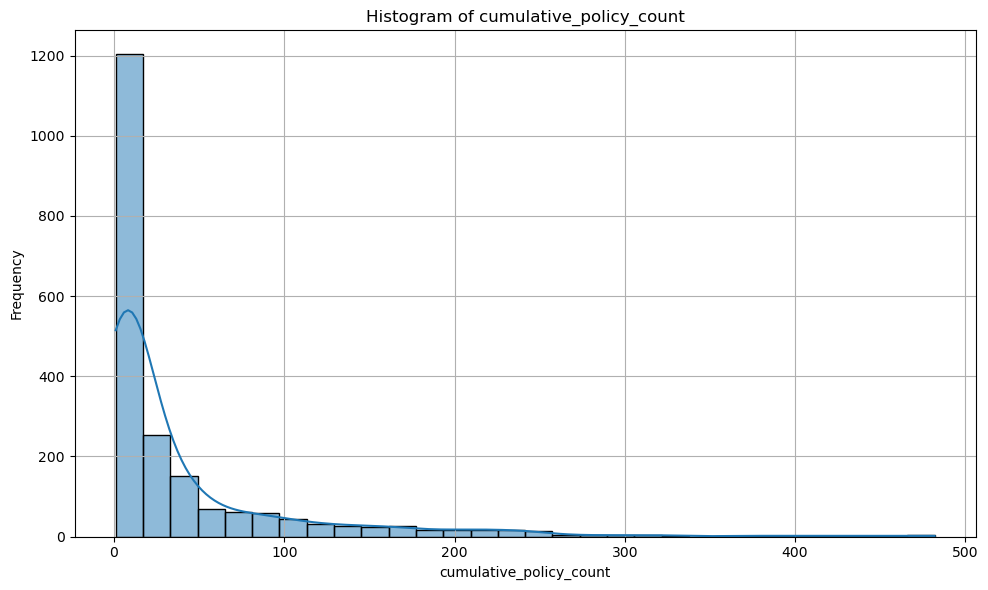

In [24]:
eda_utils.plot_simple_histogram(policy_index_agg, "cumulative_policy_count")

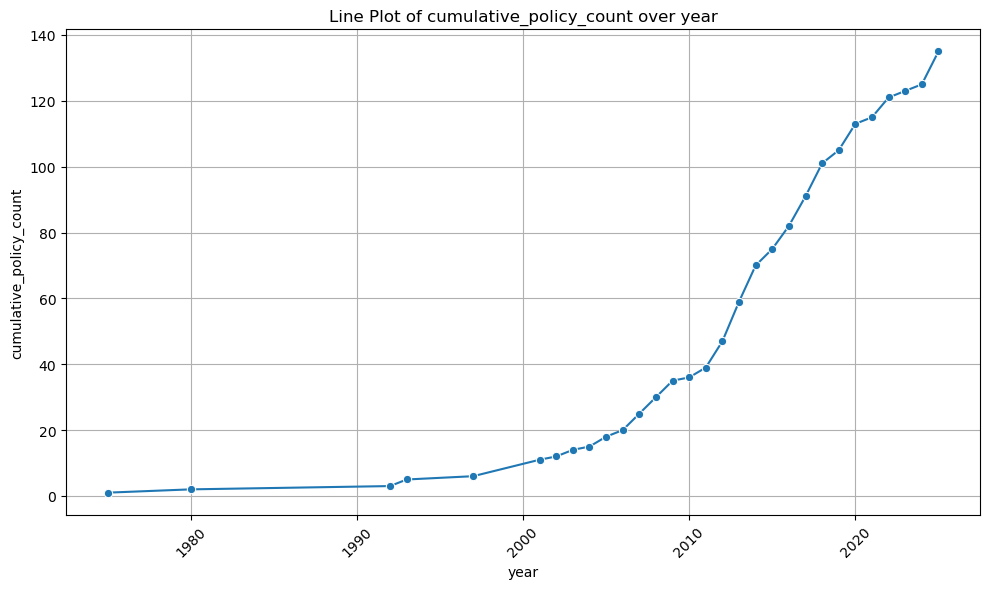

In [25]:
eda_utils.plot_simple_lineplot(policy_index_agg[policy_index_agg.iso_alpha_3 == "MEX"], "year", "cumulative_policy_count")

In [26]:
df_filtered.head()

,iso_alpha_3,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,...,inc_has_ets,inc_carbon_pricing_coverage,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
0,AFG,2002,926.507941,0.084,0.919,0.137,0.523,-1.251137,-1.587687,-2.035034,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AFG,2003,966.962032,0.086,0.919,0.129,0.550,-1.344180,-1.175768,-2.198372,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AFG,2004,971.633503,0.091,0.931,0.123,0.546,-1.350647,-0.945146,-2.295682,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AFG,2005,1076.087353,0.113,0.942,0.117,0.542,-1.447252,-1.228816,-2.067510,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AFG,2006,1121.834471,0.199,0.955,0.116,0.540,-1.446292,-1.473652,-2.219135,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
# Merge the aggregated policy index with the socio-economic data
df_filtered = df_filtered.merge(policy_index_agg, left_on=["iso_alpha_3", "year"], right_on=["iso_alpha_3", "year"], how="left")
df_filtered = df_filtered.sort_values(["iso_alpha_3", "year"])
df_filtered[["policy_count", "cumulative_policy_count"]] = (
    df_filtered
    .groupby("iso_alpha_3")[["policy_count", "cumulative_policy_count"]]
    .ffill()
    .fillna(0)
)
df_filtered.head()

,iso_alpha_3,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,...,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout,policy_count,cumulative_policy_count
0,AFG,2002,926.507941,0.084,0.919,0.137,0.523,-1.251137,-1.587687,-2.035034,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AFG,2003,966.962032,0.086,0.919,0.129,0.550,-1.344180,-1.175768,-2.198372,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AFG,2004,971.633503,0.091,0.931,0.123,0.546,-1.350647,-0.945146,-2.295682,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AFG,2005,1076.087353,0.113,0.942,0.117,0.542,-1.447252,-1.228816,-2.067510,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AFG,2006,1121.834471,0.199,0.955,0.116,0.540,-1.446292,-1.473652,-2.219135,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
#TODO: Test an interaction term with gov_efficiency or something like that.
df_filtered["policy_index_x_gov_eff"] = df_filtered["cumulative_policy_count"] * df_filtered["cap_govt_effectiveness"]
df_filtered["policy_index_x_corruption"] = df_filtered["cumulative_policy_count"] * df_filtered["cap_control_corruption"]
df_filtered["policy_index_x_regulatory_quality"] = df_filtered["cumulative_policy_count"] * df_filtered["cap_regulatory_quality"]

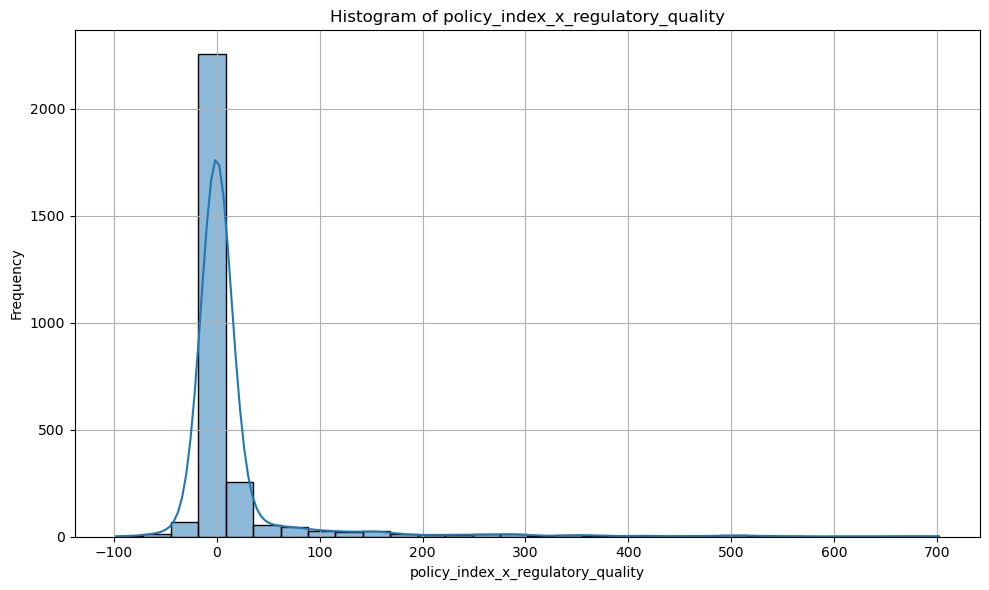

In [29]:
eda_utils.plot_simple_histogram(df_filtered, "policy_index_x_regulatory_quality")

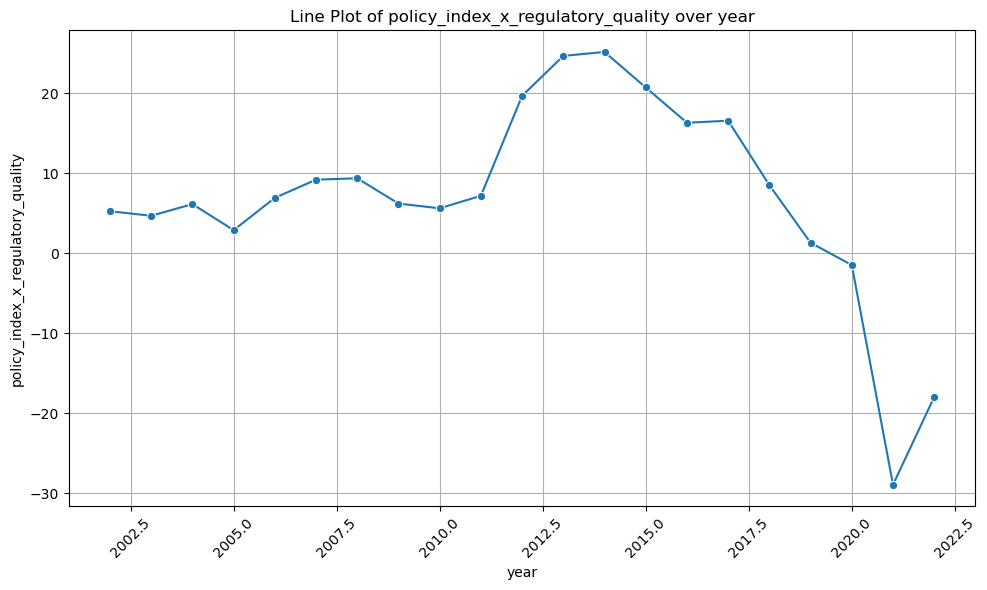

In [30]:
eda_utils.plot_simple_lineplot(df_filtered[df_filtered.iso_alpha_3 == "MEX"], "year", "policy_index_x_regulatory_quality")

In [31]:
# drop policy count field
df_filtered = df_filtered.drop(columns=["policy_count"])

### Fix Skewness

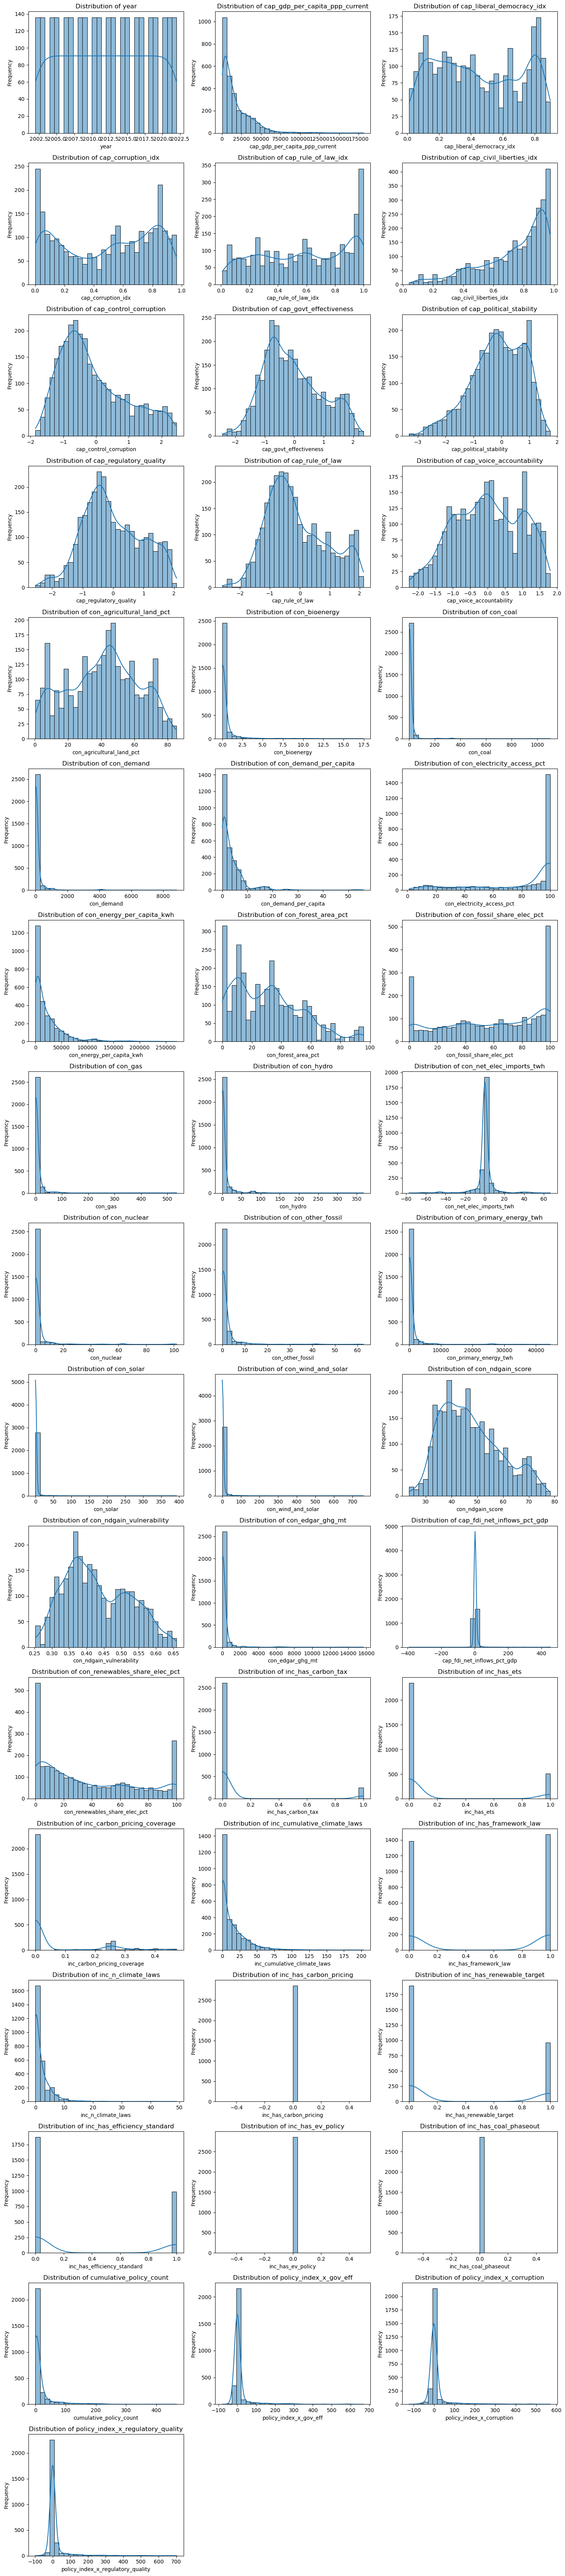

In [32]:
eda_utils.plot_numeric_fields_distributions(df_filtered)

In [33]:
df_filtered.describe()

,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,...,inc_n_climate_laws,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout,cumulative_policy_count,policy_index_x_gov_eff,policy_index_x_corruption,policy_index_x_regulatory_quality
count,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,...,2856.000000,2856.0,2856.000000,2856.000000,2856.0,2856.0,2856.000000,2856.000000,2856.000000,2856.000000
mean,2012.000000,17825.876908,0.447432,0.487975,0.575038,0.735454,-0.089537,-0.058090,-0.148709,-0.017408,...,2.184174,0.0,0.337535,0.345588,0.0,0.0,20.206583,16.655281,14.959418,15.609992
std,6.056361,20297.376882,0.262918,0.313468,0.308789,0.218340,1.015271,0.974984,0.951577,0.962821,...,3.496865,0.0,0.472952,0.475643,0.0,0.0,48.592520,69.023898,69.347691,67.705506
min,2002.000000,492.840755,0.012000,0.002000,0.010000,0.041000,-1.848734,-2.440229,-3.312951,-2.547726,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,-80.003270,-122.462410,-97.909726
25%,2007.000000,3590.244442,0.217000,0.170000,0.300500,0.608000,-0.853330,-0.784158,-0.749497,-0.709759,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,1.000000,-1.933701,-2.836038,-1.703140
50%,2012.000000,10813.936025,0.421000,0.532000,0.592500,0.806000,-0.355056,-0.200911,-0.087762,-0.177335,...,1.000000,0.0,0.000000,0.000000,0.0,0.0,4.000000,-0.000000,-0.000000,0.000000
75%,2017.000000,25802.122340,0.688000,0.784000,0.871000,0.913000,0.564135,0.596476,0.625529,0.696511,...,3.000000,0.0,1.000000,1.000000,0.0,0.0,14.000000,2.640413,1.227708,3.099806
max,2022.000000,180939.439450,0.897000,0.965000,0.999000,0.976000,2.459118,2.347191,1.753184,2.081799,...,49.000000,0.0,1.000000,1.000000,0.0,0.0,467.000000,668.582892,569.726330,701.715894


In [34]:
# Identify full o zeros and drop them
zero_cols = df_filtered.columns[(df_filtered == 0).all()]
df_filtered = df_filtered.drop(columns=zero_cols)
print(zero_cols)


Index(['inc_has_carbon_pricing', 'inc_has_ev_policy', 'inc_has_coal_phaseout'], dtype='object')


In [35]:
# Identify binary columns
binary_cols = [
    c for c in df_filtered.columns
    if df_filtered[c].nunique(dropna=True) == 2
]
binary_cols

['inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard']

In [36]:
# Identify columns with low variance and with a lot of zeros

def get_zeros_and_variance_check_df(df):
    zeros_and_variance_check = []
    for field in df.select_dtypes(np.number):
        zero_share = (df[field] == 0).mean()
        field_var = df[field].var()

        if field in binary_cols:
            binary_flag = True
        else:
            binary_flag = False


        zeros_and_variance_check.append((field, zero_share, field_var, binary_flag))

    zeros_and_variance_check_df = pd.DataFrame(data=zeros_and_variance_check, columns=["field_name", "field_zero_share", "field_variance", "bianry_flag"])
    return zeros_and_variance_check_df

In [37]:
zeros_and_variance_check_df = get_zeros_and_variance_check_df(df_filtered)

In [38]:
# zeros_and_variance_check_df.to_clipboard(index=False)

In [39]:
skew = df_filtered[[col for col in df_filtered.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew.head(20)

con_solar                            18.100333
con_wind_and_solar                   16.703063
con_coal                             10.716587
con_gas                              10.058157
con_hydro                             8.669590
cap_fdi_net_inflows_pct_gdp           8.480725
con_edgar_ghg_mt                      8.467774
con_demand                            8.351667
con_primary_energy_twh                7.524785
con_nuclear                           6.399152
con_other_fossil                      6.160889
con_bioenergy                         5.676543
policy_index_x_regulatory_quality     5.547082
policy_index_x_gov_eff                5.410974
policy_index_x_corruption             4.814797
cumulative_policy_count               4.616473
con_demand_per_capita                 4.576735
inc_n_climate_laws                    4.486000
con_energy_per_capita_kwh             2.979298
inc_cumulative_climate_laws           2.726220
dtype: float64

In [40]:
skew.tail(10)

year                          0.000000
con_agricultural_land_pct    -0.079755
cap_voice_accountability     -0.111544
cap_corruption_idx           -0.148069
cap_rule_of_law_idx          -0.172612
con_fossil_share_elec_pct    -0.295079
cap_political_stability      -0.516479
con_net_elec_imports_twh     -0.981781
cap_civil_liberties_idx      -1.038481
con_electricity_access_pct   -1.156544
dtype: float64

In [41]:
highly_skewed_fields = skew[skew.abs() >= 1].index.to_list()
highly_skewed_fields

['con_solar',
 'con_wind_and_solar',
 'con_coal',
 'con_gas',
 'con_hydro',
 'cap_fdi_net_inflows_pct_gdp',
 'con_edgar_ghg_mt',
 'con_demand',
 'con_primary_energy_twh',
 'con_nuclear',
 'con_other_fossil',
 'con_bioenergy',
 'policy_index_x_regulatory_quality',
 'policy_index_x_gov_eff',
 'policy_index_x_corruption',
 'cumulative_policy_count',
 'con_demand_per_capita',
 'inc_n_climate_laws',
 'con_energy_per_capita_kwh',
 'inc_cumulative_climate_laws',
 'cap_gdp_per_capita_ppp_current',
 'inc_carbon_pricing_coverage',
 'cap_civil_liberties_idx',
 'con_electricity_access_pct']

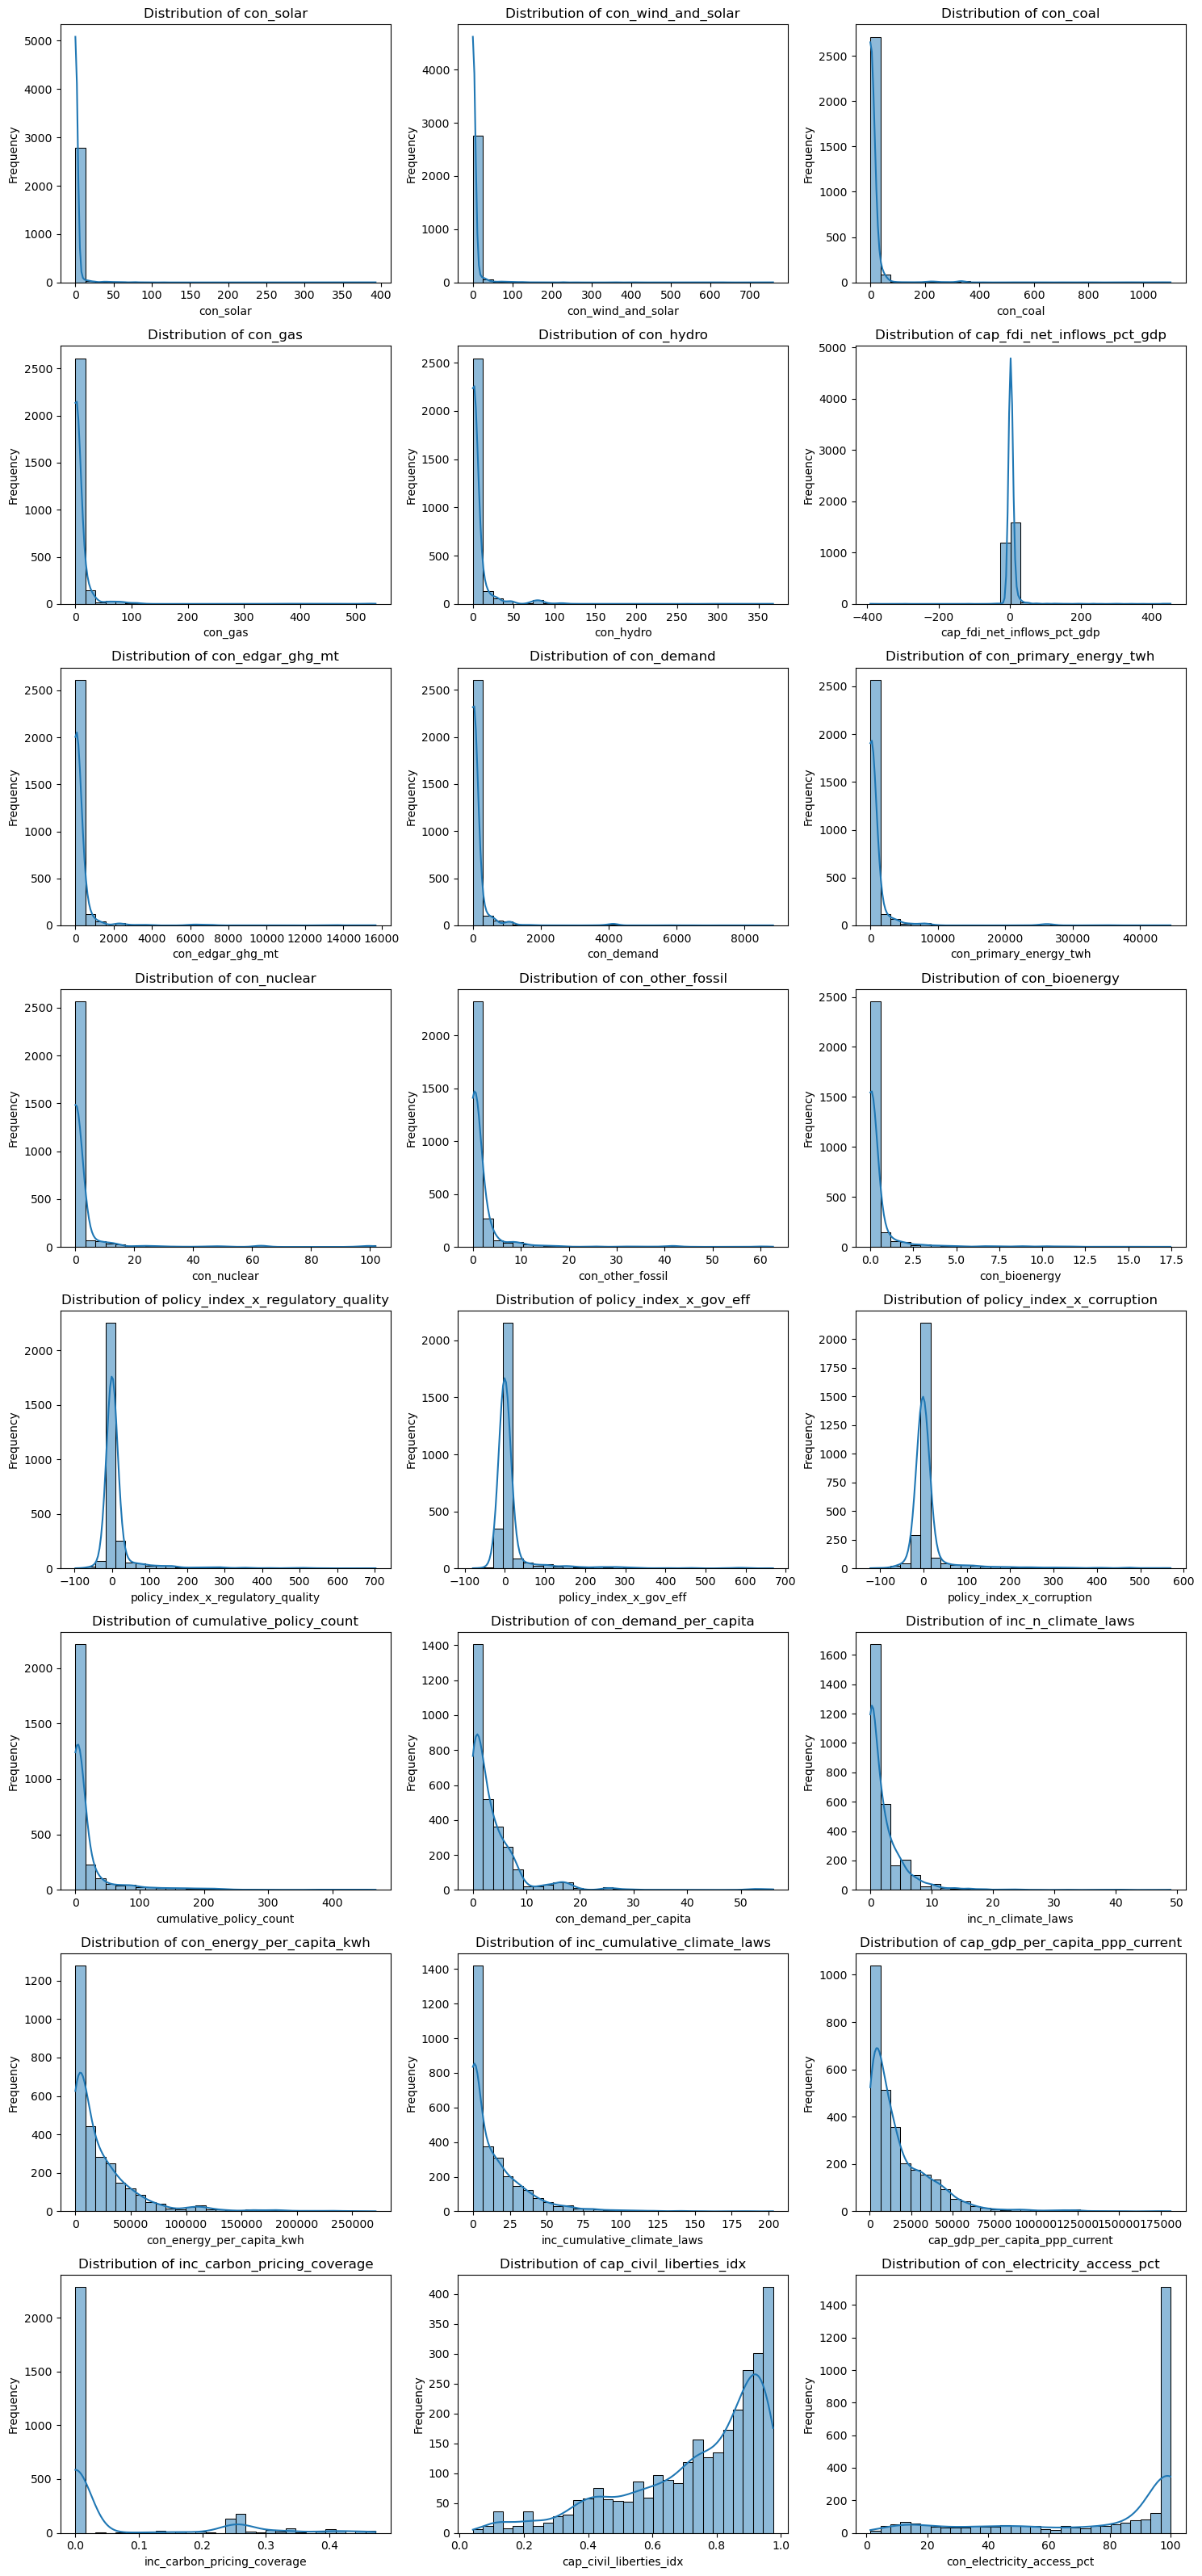

In [42]:
eda_utils.plot_numeric_fields_distributions(df_filtered[highly_skewed_fields])

### Second pass to fix skewness using log transformation

In [43]:
# Log transform highly skewed fields
for field in highly_skewed_fields:
    df_filtered[f"x_log_signed_{field}"] = np.sign(df_filtered[field]) * np.log1p(np.abs(df_filtered[field]))
df_filtered.head()

,iso_alpha_3,year,cap_gdp_per_capita_ppp_current,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_civil_liberties_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,...,x_log_signed_policy_index_x_corruption,x_log_signed_cumulative_policy_count,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,926.507941,0.084,0.919,0.137,0.523,-1.251137,-1.587687,-2.035034,...,0.0,0.0,0.039221,0.0,5.054301,0.0,6.832501,0.0,0.420682,2.714695
1,AFG,2003,966.962032,0.086,0.919,0.129,0.550,-1.344180,-1.175768,-2.198372,...,0.0,0.0,0.039221,0.0,5.167969,0.0,6.875193,0.0,0.438255,2.995732
2,AFG,2004,971.633503,0.091,0.931,0.123,0.546,-1.350647,-0.945146,-2.295682,...,0.0,0.0,0.039221,0.0,5.067381,0.0,6.880007,0.0,0.435671,3.210844
3,AFG,2005,1076.087353,0.113,0.942,0.117,0.542,-1.447252,-1.228816,-2.067510,...,0.0,0.0,0.039221,0.0,5.330145,0.0,6.982016,0.0,0.433080,3.391147
4,AFG,2006,1121.834471,0.199,0.955,0.116,0.540,-1.446292,-1.473652,-2.219135,...,0.0,0.0,0.048790,0.0,5.552444,0.0,7.023612,0.0,0.431782,3.540959


In [44]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 71 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     2856 non-null   object 
 1   year                                            2856 non-null   int64  
 2   cap_gdp_per_capita_ppp_current                  2856 non-null   float64
 3   cap_liberal_democracy_idx                       2856 non-null   float64
 4   cap_corruption_idx                              2856 non-null   float64
 5   cap_rule_of_law_idx                             2856 non-null   float64
 6   cap_civil_liberties_idx                         2856 non-null   float64
 7   cap_control_corruption                          2856 non-null   float64
 8   cap_govt_effectiveness                          2856 non-null   float64
 9   cap_political_stability                  

In [45]:
# Drop the skewed fields since we have the log transform version
df_log_transformed = df_filtered.drop(columns=highly_skewed_fields)

In [46]:
skew_after_log_transform = df_log_transformed[[col for col in df_log_transformed.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew_after_log_transform.head(20)

x_log_signed_con_solar                            4.072531
x_log_signed_con_bioenergy                        3.204910
x_log_signed_con_wind_and_solar                   2.861822
x_log_signed_con_nuclear                          2.769048
x_log_signed_con_coal                             2.328500
x_log_signed_con_other_fossil                     1.994020
x_log_signed_inc_carbon_pricing_coverage          1.766301
x_log_signed_con_hydro                            1.589147
x_log_signed_con_gas                              1.486547
x_log_signed_policy_index_x_gov_eff               0.908199
x_log_signed_policy_index_x_corruption            0.859267
x_log_signed_policy_index_x_regulatory_quality    0.722520
cap_control_corruption                            0.719912
con_forest_area_pct                               0.669409
x_log_signed_con_demand                           0.665992
x_log_signed_inc_n_climate_laws                   0.635581
x_log_signed_cumulative_policy_count              0.6262

In [47]:
zeros_and_variance_check_df_after_transformation = get_zeros_and_variance_check_df(df_log_transformed)
zeros_and_variance_check_df_after_transformation.head()

,field_name,field_zero_share,field_variance,bianry_flag
0,year,0.0,36.679510,False
1,cap_liberal_democracy_idx,0.0,0.069126,False
2,cap_corruption_idx,0.0,0.098262,False
3,cap_rule_of_law_idx,0.0,0.095350,False
4,cap_control_corruption,0.0,1.030776,False


In [48]:
# zeros_and_variance_check_df_after_transformation.to_clipboard()

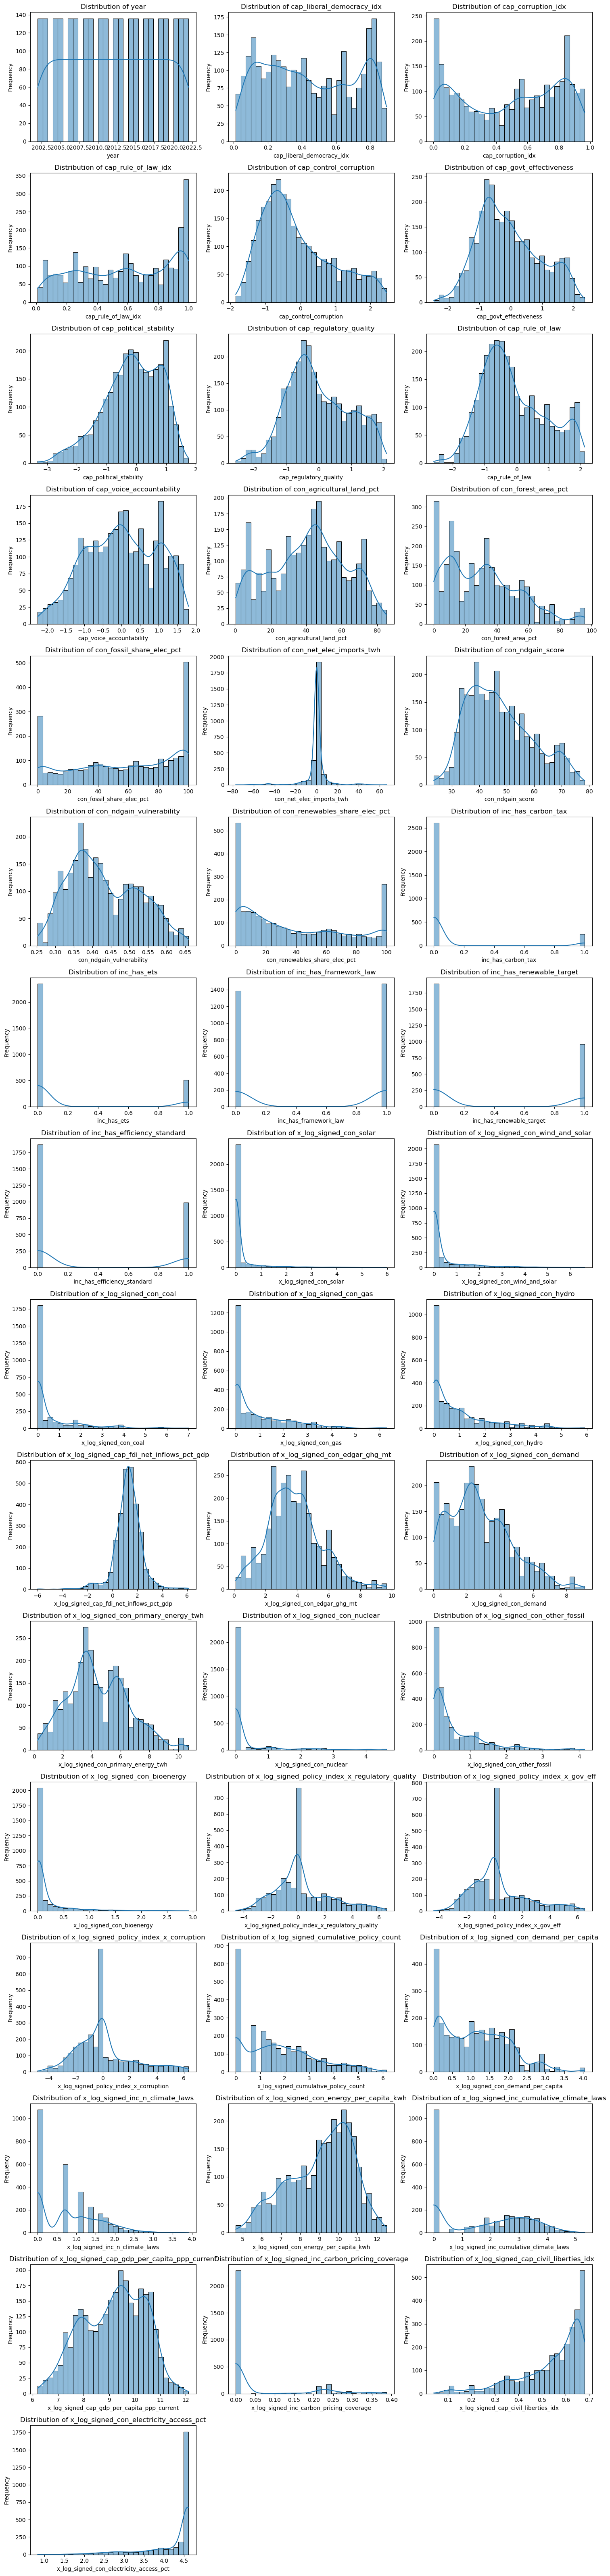

In [49]:
eda_utils.plot_numeric_fields_distributions(df_log_transformed)

In [50]:
df_log_transformed.columns

Index(['iso_alpha_3', 'year', 'cap_liberal_democracy_idx',
       'cap_corruption_idx', 'cap_rule_of_law_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_political_stability',
       'cap_regulatory_quality', 'cap_rule_of_law', 'cap_voice_accountability',
       'con_agricultural_land_pct', 'con_forest_area_pct',
       'con_fossil_share_elec_pct', 'con_net_elec_imports_twh',
       'con_ndgain_score', 'con_ndgain_vulnerability',
       'con_renewables_share_elec_pct', 'inc_has_carbon_tax', 'inc_has_ets',
       'inc_has_framework_law', 'inc_has_renewable_target',
       'inc_has_efficiency_standard', 'x_log_signed_con_solar',
       'x_log_signed_con_wind_and_solar', 'x_log_signed_con_coal',
       'x_log_signed_con_gas', 'x_log_signed_con_hydro',
       'x_log_signed_cap_fdi_net_inflows_pct_gdp',
       'x_log_signed_con_edgar_ghg_mt', 'x_log_signed_con_demand',
       'x_log_signed_con_primary_energy_twh', 'x_log_signed_con_nuclear',
       'x_log_signed_con_oth

### Generate lags

In [51]:
policy_lag_base_features = [
    "inc_has_efficiency_standard",
    "inc_has_renewable_target",
    "inc_has_carbon_tax",
    "inc_has_ets",
    "x_log_signed_inc_carbon_pricing_coverage",
    "x_log_signed_inc_n_climate_laws"
]

policy_lag_specs = {
    feature: [1, 2]
    for feature in policy_lag_base_features
}

for feature in [
    "inc_has_efficiency_standard",
    "inc_has_renewable_target",
    "inc_has_carbon_tax",
    "inc_has_ets",
]:
    policy_lag_specs[feature] = [1, 2, 3]

missing_policy_lag_features = [
    feature for feature in policy_lag_base_features
    if feature not in df_log_transformed.columns
]

if missing_policy_lag_features:
    raise KeyError(f"Missing policy lag features: {missing_policy_lag_features}")

df_log_transformed = (
    df_log_transformed
    .sort_values(["iso_alpha_3", "year"])
    .reset_index(drop=True)
    .copy()
)

policy_lag_feature_cols = []

for feature, lag_years in policy_lag_specs.items():
    for lag_year in lag_years:
        lag_col = f"{feature}_lag_{lag_year}y"
        df_log_transformed[lag_col] = (
            df_log_transformed
            .groupby("iso_alpha_3", sort=False)[feature]
            .shift(lag_year)
        )
        policy_lag_feature_cols.append(lag_col)

policy_lag_feature_cols

['inc_has_efficiency_standard_lag_1y',
 'inc_has_efficiency_standard_lag_2y',
 'inc_has_efficiency_standard_lag_3y',
 'inc_has_renewable_target_lag_1y',
 'inc_has_renewable_target_lag_2y',
 'inc_has_renewable_target_lag_3y',
 'inc_has_carbon_tax_lag_1y',
 'inc_has_carbon_tax_lag_2y',
 'inc_has_carbon_tax_lag_3y',
 'inc_has_ets_lag_1y',
 'inc_has_ets_lag_2y',
 'inc_has_ets_lag_3y',
 'x_log_signed_inc_carbon_pricing_coverage_lag_1y',
 'x_log_signed_inc_carbon_pricing_coverage_lag_2y',
 'x_log_signed_inc_n_climate_laws_lag_1y',
 'x_log_signed_inc_n_climate_laws_lag_2y']

In [52]:
df_log_transformed[
    ["iso_alpha_3", "year"] + policy_lag_base_features + policy_lag_feature_cols
].head(10)

,iso_alpha_3,year,inc_has_efficiency_standard,inc_has_renewable_target,inc_has_carbon_tax,inc_has_ets,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_inc_n_climate_laws,inc_has_efficiency_standard_lag_1y,inc_has_efficiency_standard_lag_2y,...,inc_has_carbon_tax_lag_1y,inc_has_carbon_tax_lag_2y,inc_has_carbon_tax_lag_3y,inc_has_ets_lag_1y,inc_has_ets_lag_2y,inc_has_ets_lag_3y,x_log_signed_inc_carbon_pricing_coverage_lag_1y,x_log_signed_inc_carbon_pricing_coverage_lag_2y,x_log_signed_inc_n_climate_laws_lag_1y,x_log_signed_inc_n_climate_laws_lag_2y
0,AFG,2002,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,2003,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,...,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.000000,NaN
2,AFG,2004,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.000000,0.000000
3,AFG,2005,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
4,AFG,2006,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
5,AFG,2007,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
6,AFG,2008,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,0.000000
7,AFG,2009,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,0.693147
8,AFG,2010,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,0.693147
9,AFG,2011,0.0,0.0,0.0,0.0,0.0,1.386294,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.693147


## ML

In [53]:
# Sort the dataframe by country and year to ensure proper temporal ordering for modeling
training_df = df_log_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
training_df.head()

,iso_alpha_3,year,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,cap_rule_of_law,...,inc_has_carbon_tax_lag_1y,inc_has_carbon_tax_lag_2y,inc_has_carbon_tax_lag_3y,inc_has_ets_lag_1y,inc_has_ets_lag_2y,inc_has_ets_lag_3y,x_log_signed_inc_carbon_pricing_coverage_lag_1y,x_log_signed_inc_carbon_pricing_coverage_lag_2y,x_log_signed_inc_n_climate_laws_lag_1y,x_log_signed_inc_n_climate_laws_lag_2y
0,AFG,2002,0.084,0.919,0.137,-1.251137,-1.587687,-2.035034,-1.811546,-1.673473,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,2003,0.086,0.919,0.129,-1.344180,-1.175768,-2.198372,-1.463108,-1.558294,...,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN
2,AFG,2004,0.091,0.931,0.123,-1.350647,-0.945146,-2.295682,-1.511549,-1.693925,...,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0
3,AFG,2005,0.113,0.942,0.117,-1.447252,-1.228816,-2.067510,-1.643440,-1.662966,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AFG,2006,0.199,0.955,0.116,-1.446292,-1.473652,-2.219135,-1.689469,-1.879005,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
training_df.year.max()

np.int64(2022)

In [55]:
target_var = "x_log_signed_con_edgar_ghg_mt"

In [56]:
training_df = training_df.sort_values(["iso_alpha_3", "year"]).copy()

# # ================================
# # 1. 1-year lag of emissions (no leakage)
# # ================================

training_df["em_lag_1y"] = (
    training_df
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .shift(1)
)

# ================================
# Helper function to compute slope
# ================================

def compute_slope(series):
    x = np.arange(len(series))
    y = series.values
    return np.polyfit(x, y, 1)[0]


# ================================
# 2. 3-year rolling trend
# ================================

training_df["em_trend_3y"] = (
    training_df
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=3, min_periods=2)
    .apply(compute_slope, raw=False)
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df["em_trend_3y"] = (
    training_df
    .groupby("iso_alpha_3")["em_trend_3y"]
    .shift(1)
)


# ================================
# 3. 5-year rolling trend
# ================================

training_df["em_trend_5y"] = (
    training_df
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=5, min_periods=3)
    .apply(compute_slope, raw=False)
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df["em_trend_5y"] = (
    training_df
    .groupby("iso_alpha_3")["em_trend_5y"]
    .shift(1)
)


# ================================
# 4. Trend acceleration
# ================================

training_df["em_acceleration"] = (
    training_df["em_trend_3y"] -
    training_df["em_trend_5y"]
)


# ================================
# 5. Rolling volatility (5y std)
# ================================

training_df["em_volatility_5y"] = (
    training_df
    .groupby("iso_alpha_3")["x_log_signed_con_edgar_ghg_mt"]
    .rolling(window=5, min_periods=3)
    .std()
    .reset_index(level=0, drop=True)
)

# shift to avoid leakage
training_df["em_volatility_5y"] = (
    training_df
    .groupby("iso_alpha_3")["em_volatility_5y"]
    .shift(1)
)

In [57]:
training_df = training_df.dropna()
training_df

,iso_alpha_3,year,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,cap_rule_of_law,...,inc_has_ets_lag_3y,x_log_signed_inc_carbon_pricing_coverage_lag_1y,x_log_signed_inc_carbon_pricing_coverage_lag_2y,x_log_signed_inc_n_climate_laws_lag_1y,x_log_signed_inc_n_climate_laws_lag_2y,em_lag_1y,em_trend_3y,em_trend_5y,em_acceleration,em_volatility_5y
3,AFG,2005,0.113,0.942,0.117,-1.447252,-1.228816,-2.067510,-1.643440,-1.662966,...,0.0,0.0,0.0,0.000000,0.000000,2.933296,0.020222,0.020222,0.000000,0.022522
4,AFG,2006,0.199,0.955,0.116,-1.446292,-1.473652,-2.219135,-1.689469,-1.879005,...,0.0,0.0,0.0,0.000000,0.000000,2.954458,0.012104,0.018786,-0.006682,0.025614
5,AFG,2007,0.200,0.957,0.112,-1.613251,-1.440111,-2.413373,-1.708872,-1.852560,...,0.0,0.0,0.0,0.000000,0.000000,2.968414,0.017559,0.017533,0.000026,0.028694
6,AFG,2008,0.202,0.957,0.110,-1.672096,-1.527795,-2.691361,-1.607167,-1.903308,...,0.0,0.0,0.0,0.693147,0.000000,3.026143,0.035842,0.022690,0.013152,0.038868
7,AFG,2009,0.198,0.957,0.114,-1.552299,-1.507752,-2.711421,-1.664508,-1.876119,...,0.0,0.0,0.0,0.693147,0.693147,3.181789,0.106687,0.056867,0.049820,0.100536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,ZWE,2018,0.211,0.762,0.255,-1.246380,-1.297955,-0.721012,-1.525652,-1.293059,...,0.0,0.0,0.0,1.791759,0.000000,3.407011,-0.038810,-0.026694,-0.012115,0.047119
2852,ZWE,2019,0.197,0.765,0.227,-1.290334,-1.310435,-0.943303,-1.486515,-1.311041,...,0.0,0.0,0.0,1.386294,1.791759,3.474243,0.025367,-0.004123,0.029490,0.033050
2853,ZWE,2020,0.192,0.795,0.233,-1.308788,-1.342368,-1.052743,-1.434415,-1.337362,...,0.0,0.0,0.0,1.609438,1.386294,3.440653,0.016821,-0.003722,0.020543,0.032957
2854,ZWE,2021,0.188,0.826,0.215,-1.277147,-1.290561,-0.954443,-1.386109,-1.282122,...,0.0,0.0,0.0,2.079442,1.609438,3.379005,-0.047619,-0.005536,-0.042082,0.035746


In [58]:
features_list = training_df.columns[
    ~training_df.columns.isin(["iso_alpha_3", "year", target_var])
].tolist()

features_list

['cap_liberal_democracy_idx',
 'cap_corruption_idx',
 'cap_rule_of_law_idx',
 'cap_control_corruption',
 'cap_govt_effectiveness',
 'cap_political_stability',
 'cap_regulatory_quality',
 'cap_rule_of_law',
 'cap_voice_accountability',
 'con_agricultural_land_pct',
 'con_forest_area_pct',
 'con_fossil_share_elec_pct',
 'con_net_elec_imports_twh',
 'con_ndgain_score',
 'con_ndgain_vulnerability',
 'con_renewables_share_elec_pct',
 'inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard',
 'x_log_signed_con_solar',
 'x_log_signed_con_wind_and_solar',
 'x_log_signed_con_coal',
 'x_log_signed_con_gas',
 'x_log_signed_con_hydro',
 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
 'x_log_signed_con_demand',
 'x_log_signed_con_primary_energy_twh',
 'x_log_signed_con_nuclear',
 'x_log_signed_con_other_fossil',
 'x_log_signed_con_bioenergy',
 'x_log_signed_policy_index_x_regulatory_quality',
 'x_log_signed_policy_index_x_gov_eff',
 'x

In [59]:
enet_params = dict(
    l1_ratio=[0.01],
    n_alphas=300,          # wider alpha search
    eps=1e-4,              # allow smaller alphas
    cv=7,
    max_iter=30000,
    n_jobs=1,
    random_state=42,
)


ra_ablation = RegressionAnalysis(
    df=training_df,
    target_col=target_var,
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=5,
    scaler_type="standard",
    feature_cols=features_list,
    include_year=False,
    enet_params=enet_params
)


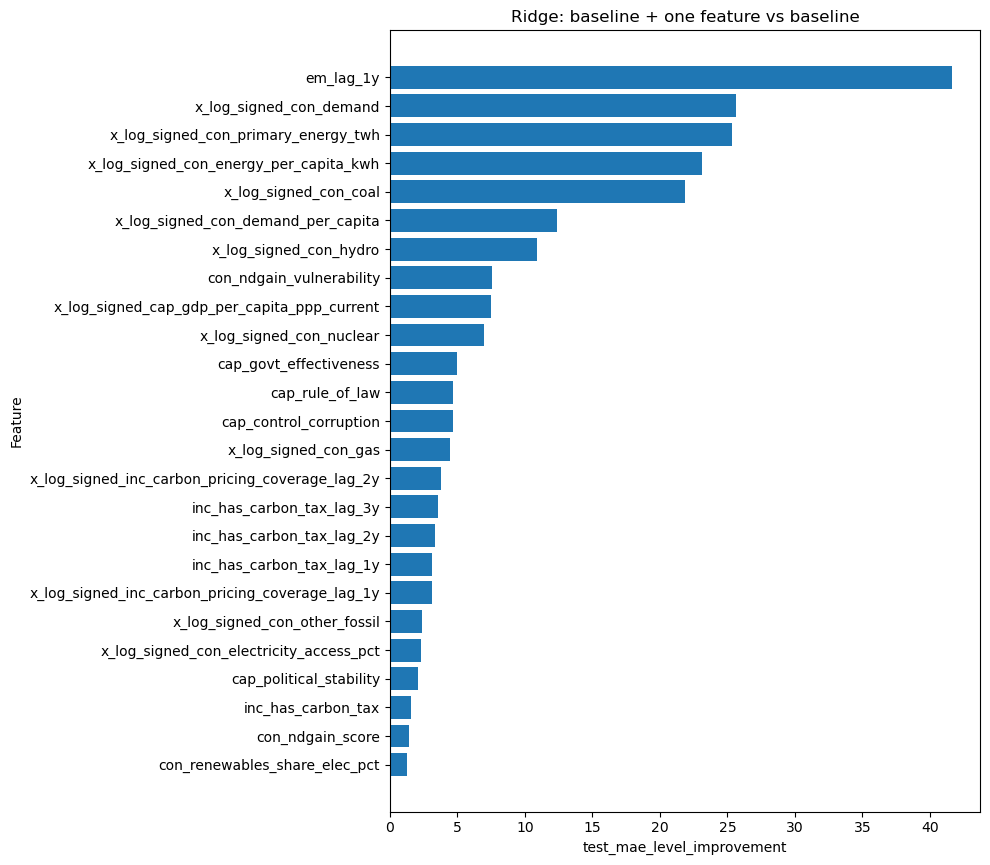

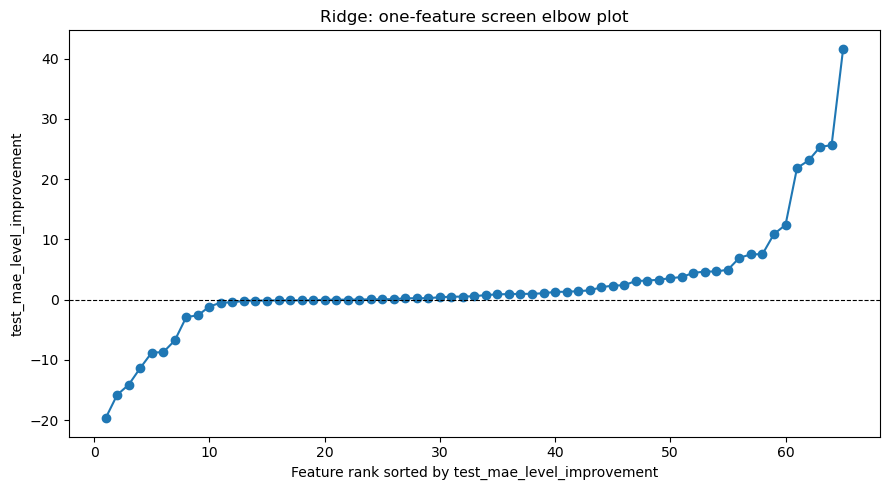

In [60]:
feature_screen_df = ra_ablation.single_feature_baseline_experiment(
    features=features_list,
    model="Ridge",
    include_group=True,
    include_year_trend=True,
    dropna=True,
    sort_by="test_mae_level_improvement",
    ascending=False,
    plot=True,
    top_n=25,
)

In [61]:
feature_screen_df.to_clipboard(index=False)

In [66]:
# Get the feattures with test_mae_level_improvement above 0
top_features = feature_screen_df[feature_screen_df["test_mae_level_improvement"] > 0]["feature"].tolist()
top_features


['em_lag_1y',
 'x_log_signed_con_demand',
 'x_log_signed_con_primary_energy_twh',
 'x_log_signed_con_energy_per_capita_kwh',
 'x_log_signed_con_coal',
 'x_log_signed_con_demand_per_capita',
 'x_log_signed_con_hydro',
 'con_ndgain_vulnerability',
 'x_log_signed_cap_gdp_per_capita_ppp_current',
 'x_log_signed_con_nuclear',
 'cap_govt_effectiveness',
 'cap_rule_of_law',
 'cap_control_corruption',
 'x_log_signed_con_gas',
 'x_log_signed_inc_carbon_pricing_coverage_lag_2y',
 'inc_has_carbon_tax_lag_3y',
 'inc_has_carbon_tax_lag_2y',
 'inc_has_carbon_tax_lag_1y',
 'x_log_signed_inc_carbon_pricing_coverage_lag_1y',
 'x_log_signed_con_other_fossil',
 'x_log_signed_con_electricity_access_pct',
 'cap_political_stability',
 'inc_has_carbon_tax',
 'con_ndgain_score',
 'con_renewables_share_elec_pct',
 'inc_has_ets_lag_3y',
 'x_log_signed_cap_civil_liberties_idx',
 'cap_regulatory_quality',
 'inc_has_renewable_target_lag_2y',
 'inc_has_renewable_target_lag_1y',
 'x_log_signed_policy_index_x_regulat

In [63]:
# Get the features to remove
features_to_remove = feature_screen_df[~feature_screen_df["feature"].isin(top_features)]["feature"].tolist()
features_to_remove

['cap_rule_of_law_idx',
 'x_log_signed_inc_n_climate_laws_lag_2y',
 'con_agricultural_land_pct',
 'x_log_signed_inc_n_climate_laws_lag_1y',
 'cap_corruption_idx',
 'x_log_signed_inc_n_climate_laws',
 'inc_has_framework_law',
 'x_log_signed_inc_cumulative_climate_laws',
 'inc_has_efficiency_standard_lag_1y',
 'em_acceleration',
 'con_fossil_share_elec_pct',
 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
 'inc_has_ets',
 'em_trend_3y',
 'em_volatility_5y',
 'con_forest_area_pct',
 'x_log_signed_policy_index_x_corruption',
 'em_trend_5y',
 'x_log_signed_con_bioenergy',
 'x_log_signed_con_wind_and_solar',
 'x_log_signed_con_solar',
 'x_log_signed_policy_index_x_gov_eff']

In [64]:
training_df_after_ablation = training_df.drop(columns=features_to_remove)
training_df_after_ablation.head()

,iso_alpha_3,year,cap_liberal_democracy_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,cap_regulatory_quality,cap_rule_of_law,cap_voice_accountability,con_net_elec_imports_twh,...,inc_has_renewable_target_lag_3y,inc_has_carbon_tax_lag_1y,inc_has_carbon_tax_lag_2y,inc_has_carbon_tax_lag_3y,inc_has_ets_lag_1y,inc_has_ets_lag_2y,inc_has_ets_lag_3y,x_log_signed_inc_carbon_pricing_coverage_lag_1y,x_log_signed_inc_carbon_pricing_coverage_lag_2y,em_lag_1y
3,AFG,2005,0.113,-1.447252,-1.228816,-2.067510,-1.643440,-1.662966,-1.125430,0.10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.933296
4,AFG,2006,0.199,-1.446292,-1.473652,-2.219135,-1.689469,-1.879005,-1.110294,0.43,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.954458
5,AFG,2007,0.200,-1.613251,-1.440111,-2.413373,-1.708872,-1.852560,-1.057654,0.61,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.968414
6,AFG,2008,0.202,-1.672096,-1.527795,-2.691361,-1.607167,-1.903308,-1.168902,0.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.026143
7,AFG,2009,0.198,-1.552299,-1.507752,-2.711421,-1.664508,-1.876119,-1.375495,1.15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.181789


In [65]:
print("Running regression without group feature...")
ra_training = RegressionAnalysis(
    df=training_df_after_ablation,
    target_col=target_var,
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=5,
    scaler_type="standard",
    feature_cols=top_features,
    include_year=False,
    enet_params=enet_params
)


ra_training.cross_validate()
ra_training.fit()
ra_training.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_desc

ElasticNet            0.0694          nan
RandomForest          0.0441       0.0892
XGBoost               0.0581       0.1313
Median                1.3284       1.3421


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.0638         0.0725            0.0822            0.0928               12.40               19.03
RandomForest            0.0130         0.0447            0.0189            0.0610                3.49               22.82
XGBoost                 0.0125         0.0591            0.0161            0.0849                2.58               33.32
Median                  1.3335         1.3100            1.7195            1.7094              274.28              302.46


{'ElasticNet': {'train_mae_log': 0.06377560281206018,
  'test_mae_log': 0.07248343878386848,
  'train_rmse_log': 0.08222816842907843,
  'test_rmse_log': 0.09281843964251318,
  'train_mae_level': np.float64(12.398922105074263),
  'test_mae_level': np.float64(19.02679995760219)},
 'RandomForest': {'train_mae_log': 0.012978774296628174,
  'test_mae_log': 0.04474879770519356,
  'train_rmse_log': 0.018854443402063863,
  'test_rmse_log': 0.06097166667733337,
  'train_mae_level': np.float64(3.4938937391737928),
  'test_mae_level': np.float64(22.819659793042955)},
 'XGBoost': {'train_mae_log': 0.012470728136544434,
  'test_mae_log': 0.05906423017227907,
  'train_rmse_log': 0.01606388734823634,
  'test_rmse_log': 0.08493228308759168,
  'train_mae_level': np.float64(2.5838479579540263),
  'test_mae_level': np.float64(33.3172079880582)},
 'Median': {'train_mae_log': 1.3334542694535736,
  'test_mae_log': 1.3099591138909121,
  'train_rmse_log': 1.7194713974328732,
  'test_rmse_log': 1.7093609353494

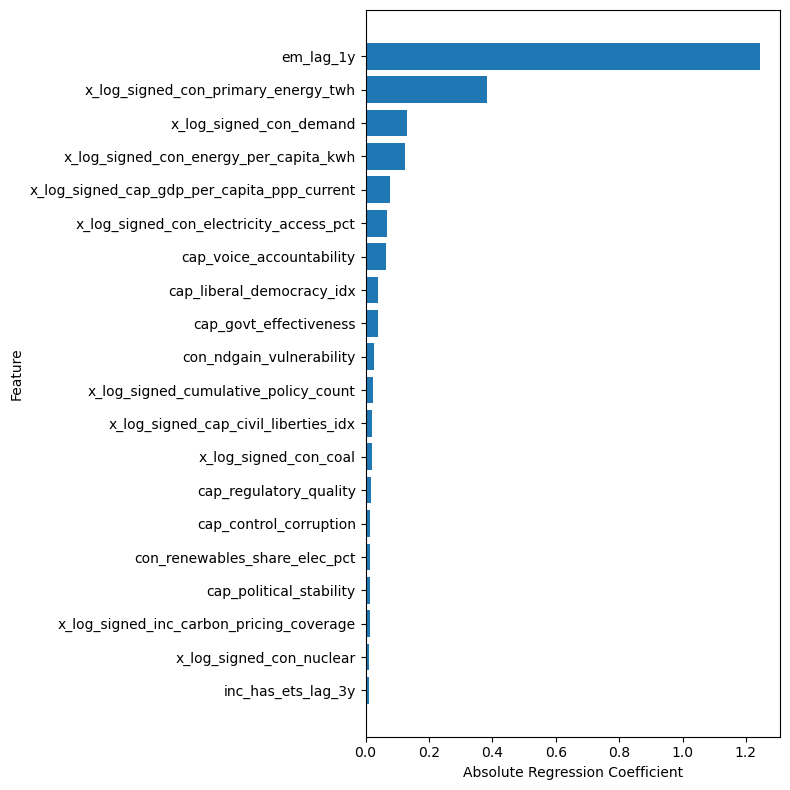

In [67]:
ra_training.plot_top_enet_regressors(n=20)

In [ ]:
# one model
ra_training.get_model_hyperparameters("ElasticNet")

{'ElasticNet': {'is_fitted': True,
  'hyperparameters': {'alphas': 'warn',
   'copy_X': True,
   'cv': TimeSeriesSplit(gap=0, max_train_size=None, n_splits=7, test_size=None),
   'eps': 0.0001,
   'fit_intercept': True,
   'l1_ratio': [0.01],
   'max_iter': 30000,
   'n_alphas': 300,
   'n_jobs': 1,
   'positive': False,
   'precompute': 'auto',
   'random_state': 42,
   'selection': 'cyclic',
   'tol': 0.0001,
   'verbose': 0},
  'selected_alpha': 0.016210330580670517,
  'selected_l1_ratio': 0.01,
  'n_iter': 193}}

In [ ]:
# df_l1 = ra_4.enet_l1_ratio_experiment(
#     l1_ratios=[0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
#     plot=True,
# )
# df_l1

### Save model

In [ ]:
# obtain timestamp
timestamp = int(time.time())

In [ ]:
# --------------------------------------------------
# Save the training data with predictions
# --------------------------------------------------
training_df_after_ablation.to_csv(
    os.path.join(TRAINING_DIR_PATH, f"training_df_{timestamp}.csv"),
    index=False
)

# --------------------------------------------------
# Select trained pipelines to save
# --------------------------------------------------
trained_pipelines = {
    "enet": ra_training.pipe_enet,   # <- THIS is the key line
}

rewrite_existing_models = False

# --------------------------------------------------
# Save pipelines
# --------------------------------------------------
for name, pipeline in trained_pipelines.items():
    model_file_name = f"{name}_pipeline_{timestamp}.pkl"
    model_path = os.path.join(MODELS_DIR_PATH, model_file_name)

    if os.path.exists(model_path) and not rewrite_existing_models:
        print(f"Model {model_file_name} already exists. Skipping save.")
        continue

    if os.path.exists(model_path):
        print(f"Overwriting existing model at {model_path}")
    else:
        print(f"Saving model to {model_path}")

    joblib.dump(pipeline, model_path)